## Import

In [ ]:
import torch
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import numpy as np
import shutil

In [6]:
from model import *
from dataset_loader import *
from uv_dewarp import *
# auto reload
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Training boilerplate

In [5]:
def visualize_and_save_uv(model, val_loader, epoch, save_dir, device):
    model.eval()

    batch = next(iter(val_loader))
    rgb = batch['rgb'][:2].to(device)
    gt_uv = batch['uv'][:2].to(device)

    with torch.no_grad():
        pred_uv = model(rgb)

    # Save tensors + filename for later dewarping
    torch.save({
        'rgb': batch['rgb'][:2],
        'pred_uv': pred_uv.cpu(),
        'gt_uv': gt_uv.cpu(),
        'filenames': batch['filename'][:2],  # so you can reload raw RGB later
    }, os.path.join(save_dir, f'uv_epoch_{epoch:03d}.pt'))

    # Save PNG so you can monitor progress just by looking at Drive
    mean = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1).to(device)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1).to(device)

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for i in range(2):
        inp = (rgb[i:i+1] * std + mean).squeeze(0).permute(1,2,0).cpu().numpy().clip(0,1)

        p = pred_uv[i].cpu().numpy()
        g = gt_uv[i].cpu().numpy()

        p_img = np.zeros((p.shape[1], p.shape[2], 3))
        p_img[:,:,0] = p[0].clip(0,1)
        p_img[:,:,1] = p[1].clip(0,1)

        g_img = np.zeros((g.shape[1], g.shape[2], 3))
        g_img[:,:,0] = g[0]
        g_img[:,:,1] = g[1]

        axes[i,0].imshow(inp);             axes[i,0].set_title('Input');        axes[i,0].axis('off')
        axes[i,1].imshow(p_img);           axes[i,1].set_title('Predicted UV'); axes[i,1].axis('off')
        axes[i,2].imshow(g_img);           axes[i,2].set_title('GT UV');        axes[i,2].axis('off')

    plt.suptitle(f'Epoch {epoch}')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'uv_epoch_{epoch:03d}.png'))
    plt.close()
    print(f"Saved viz for epoch {epoch}")
    model.train()

In [7]:
def trainloop(model, criterion, optimizer, train_loader, val_loader, num_epochs, checkpoint_path, model_path, viz_dir):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    best_val_loss = float('inf')
    start_epoch = 0
    train_losses = []
    val_losses = []

    if viz_dir:
        os.makedirs(viz_dir, exist_ok=True)

    if os.path.exists(checkpoint_path):
        print("Resuming from checkpoint...")
        checkpoint = torch.load(checkpoint_path)
        model.load_state_dict(checkpoint['model_state'])
        optimizer.load_state_dict(checkpoint['optimizer_state'])
        start_epoch = checkpoint['epoch']
        train_losses = checkpoint['train_losses']
        val_losses = checkpoint['val_losses']
        best_val_loss = checkpoint['best_val_loss']
        print(f"Resumed from epoch {start_epoch}")

    for epoch in range(start_epoch, num_epochs):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch+1}/{num_epochs}")
        print(f"{'='*50}")

        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch)
        print(f"Train Loss: {train_loss:.4f}")

        val_loss = validate(model, val_loader, criterion, device)
        print(f"Val Loss: {val_loss:.4f}")

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')
            shutil.copy('best_model.pth', model_path)
            print(f"Saved best model with val loss: {val_loss:.4f}")

        torch.save({
            'epoch': epoch + 1,
            'model_state': model.state_dict(),
            'optimizer_state': optimizer.state_dict(),
            'train_losses': train_losses,
            'val_losses': val_losses,
            'best_val_loss': best_val_loss,
        }, checkpoint_path)

        # if viz_dir and ((epoch + 1) % 5 == 0 or epoch == start_epoch):
        visualize_and_save_uv(model, val_loader, epoch + 1, viz_dir, device)

    print("\nTraining complete!")
    print(f"Best validation loss: {best_val_loss:.4f}")

## Training 

In [ ]:
# Configuration
DATA_DIR = 'renders/synthetic_data_pitch_sweep'
BATCH_SIZE = 8
LEARNING_RATE = 1e-4
IMG_SIZE = (256, 256)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DocumentReconstructionModel().to(device)
criterion = nn.L1Loss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)

train_loader, val_loader = get_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    img_size=IMG_SIZE,
    use_depth=False,
    use_uv=True,
    use_border=False 
)

Found 1700 samples in renders/synthetic_data_pitch_sweep
Train samples: 1360, Val samples: 340


#### Important note about training:

The below cell was run in colab with a GPU for 50 epochs. Here, I run it for 2 epochs just as a visualization of what the training looks like. After that I load the training output from the actual run on the colab GPU, and proceed with those results.

In [9]:
NUM_EPOCHS=2
CHECKPOINT_PATH = 'checkpoints/checkpoint.pth'
MODEL_PATH = "checkpoints/best_model.pth"
VIZ_PATH = "checkpoints/viz/"

trainloop(
    model, criterion, optimizer,
    train_loader, val_loader,
    num_epochs=NUM_EPOCHS,
    checkpoint_path=CHECKPOINT_PATH,
    model_path=MODEL_PATH,
    viz_dir=VIZ_PATH
)

Using device: cpu

Epoch 1/2


Epoch 1 [Train]:   0%|          | 0/170 [00:00<?, ?it/s]/Users/michaelbehrens/micromamba/envs/cs135_25f_env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Train Loss: 0.0733


Validation: 100%|██████████| 43/43 [00:40<00:00,  1.07it/s]


Val Loss: 0.0258
Saved best model with val loss: 0.0258
Saved viz for epoch 1

Epoch 2/2


Train Loss: 0.0229


Validation: 100%|██████████| 43/43 [00:39<00:00,  1.09it/s]


Val Loss: 0.0189
Saved best model with val loss: 0.0189
Saved viz for epoch 2

Training complete!
Best validation loss: 0.0189


## Loss curves

In [11]:
# TODO: to use the actual checkpoint trained above, change the file name here to CHECKPOINT_PATH
with open('models/checkpoint.pth', 'rb') as f:
    checkpoint = torch.load(f, map_location=device)

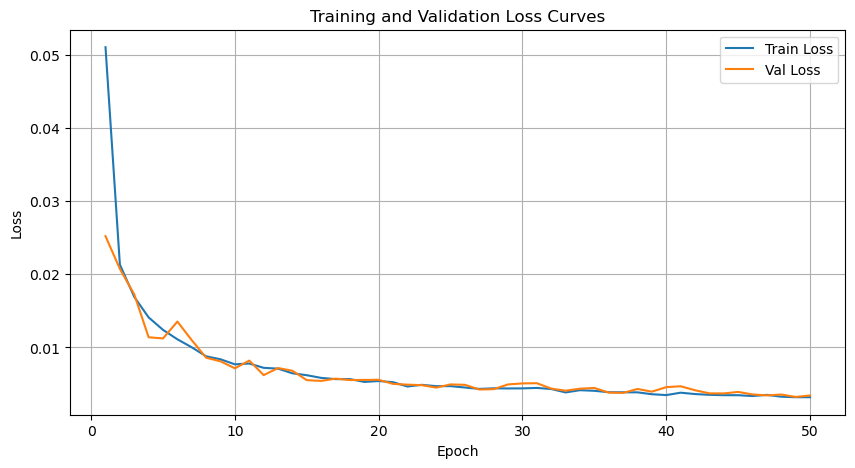

In [14]:
# plot loss curves

train_losses = checkpoint['train_losses']
val_losses = checkpoint['val_losses']
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curves')
plt.legend()
plt.grid()
plt.savefig('loss_curves.png', dpi=300, bbox_inches='tight')
plt.show()